# EDA 
Ce notebook présente une analyse exploratoire des données, suivant une **19-point checklist**:


1. **Metadata & Shape** – rows, columns, encoding, memory footprint.  

2. **Grain** – que représente une ligne ? Clé primaire naturelle ?  

3. **Data Types** – correct types? Dates as strings? IDs as floats?  

4. **Missing Values** – count per column, percentage, meaningful vs errors.  

5. **Duplicates** – exact duplicates, logical duplicates (same key).  

6. **Summary Statistics & Outliers** – min, max, mean, median; impossible values; categorical counts.  

7. **Cardinality & Key Candidates** – unique counts per column, high‑uniqueness (PK), low‑cardinality (dimensions).  

8. **Relationships & Cardinalities** – items per order, orders per customer, products per order, 1:1 relationships.  

9. **Business Context** – date range, key metrics (late delivery rate, profit margin), common values, pain points.  

10. **Entity Discovery** – group columns into Client, Product, Order, Order_Details, Shipment; extra entities needed?  

11. **Data Quality & Cleaning Plan** – columns to drop, type conversions, missing‑value strategy, standardisation.  

12. **Normalization Check** – transitive dependencies, columns belonging to more than one entity.  

13. **Data Distribution & Skew** – balance (e.g., 80/20), zeros meaning “missing” vs actual, long tail. 

14. **Temporal Integrity** – future dates, gaps in timeline, “as of” vs log, chronological order.  

15. **Referential Integrity** – foreign keys reference existing entities, impossible combinations.  

16. **Sampling & Representativeness** – sample or full population, hidden filters, data leakage.  

17. **Volatility & Freshness** – static snapshot or live, schema changes.  

18. **Domain‑Specific Sanity Checks** – calculated fields match raw fields, missing real‑world values.  

19. **Cleaning Strategy (Actionable)** – where to clean (Python/SQL), columns to split, columns to encode/hash.




**Ons** traite les questions 1 à 12 ; **Ranime** traite les questions 13 à 19.

Toutes les analyses utilisent à la fois **pandas** et **PySpark**, selon les besoins.

In [2]:
# Import pandas and PySpark
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, isnull, countDistinct

# Create Spark session
spark = SparkSession.builder.appName("EDA").getOrCreate()


In [3]:
# Load with pandas 
df = pd.read_csv('../data/raw/DataCoSupplyChainDataset.csv', encoding='latin1')
df_desc = pd.read_csv('../data/raw/DescriptionDataCoSupplyChain.csv')


In [4]:
df_desc.head()

,FIELDS,DESCRIPTION
0,Type,: Type of transaction made
1,Days for shipping (real),: Actual shipping days of the purchased product
2,Days for shipment (scheduled),: Days of scheduled delivery of the purchased...
3,Benefit per order,: Earnings per order placed
4,Sales per customer,: Total sales per customer made per customer


In [5]:
# Load with PySpark
df_spark = spark.read.csv('../data/raw/DataCoSupplyChainDataset.csv', header=True, inferSchema=True)

In [6]:
# Afficher les 10 premières lignes du DataFrame PySpark
df_spark.show(10, truncate=False)

+--------+------------------------+-----------------------------+-----------------+------------------+-----------------+------------------+-----------+--------------+-------------+----------------+--------------+--------------+-----------+--------------+-----------------+----------------+--------------+------------------------+----------------+-------------+---------------+-----------+------------+------------+----------+-------------+-----------------+-----------------------+--------+----------------------+-------------------+------------------------+-------------+------------------------+-----------------------+-------------------+------+----------------+----------------------+--------------+---------------+---------------+-------------+---------------+-------------------+-------------------+--------------------------------------------+------------+-------------+--------------+--------------------------+--------------+
|Type    |Days for shipping (real)|Days for shipment (scheduled)|

# Metadata & shape

In [7]:

print("Shape:", df.shape) #number of rows and columns
print("Memory usage:", df.memory_usage(deep=True).sum() / 1e6, "MB") #memory usage in MB (total bytes used by all columns)

df.info() #index range, column names, non-null counts, data types and memory



Shape: (180519, 53)
Memory usage: 348.798621 MB
<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str   

In [8]:
print("\nData types count:")
print(df.dtypes.value_counts())


Data types count:
str        24
float64    15
int64      14
Name: count, dtype: int64


In [9]:
print("Row count (PySpark):", df_spark.count())
print("Column count (PySpark):", len(df_spark.columns))
print("\nSchema:")
df_spark.printSchema()

Row count (PySpark): 180519
Column count (PySpark): 53

Schema:
root
 |-- Type: string (nullable = true)
 |-- Days for shipping (real): integer (nullable = true)
 |-- Days for shipment (scheduled): integer (nullable = true)
 |-- Benefit per order: double (nullable = true)
 |-- Sales per customer: double (nullable = true)
 |-- Delivery Status: string (nullable = true)
 |-- Late_delivery_risk: integer (nullable = true)
 |-- Category Id: integer (nullable = true)
 |-- Category Name: string (nullable = true)
 |-- Customer City: string (nullable = true)
 |-- Customer Country: string (nullable = true)
 |-- Customer Email: string (nullable = true)
 |-- Customer Fname: string (nullable = true)
 |-- Customer Id: integer (nullable = true)
 |-- Customer Lname: string (nullable = true)
 |-- Customer Password: string (nullable = true)
 |-- Customer Segment: string (nullable = true)
 |-- Customer State: string (nullable = true)
 |-- Customer Street: string (nullable = true)
 |-- Customer Zipcode: in

In [10]:
from collections import Counter

# Récupérer la liste des types PySpark (chaque élément est une chaîne comme 'int', 'string', 'double')
spark_type_list = [dtype for _, dtype in df_spark.dtypes]

# Compter les occurrences
type_counts = Counter(spark_type_list)

print("Data types count (PySpark) :")
for dtype, count in type_counts.items():
    print(f"{dtype}: {count}")

Data types count (PySpark) :
string: 25
int: 16
double: 12


### Dimensions
- **Pandas** : 180 519 lignes, 53 colonnes.  
- **PySpark** : 180 519 lignes, 53 colonnes – *les comptes correspondent*.

### Empreinte mémoire (pandas)
- Mémoire totale (deep) : **348,8 Mo**.  
- *`df.info()` affiche 73,0 Mo, mais cette valeur ignore les overheads Python des colonnes de type `object` ; `deep=True` donne la réalité.*

### Types de données
- **Pandas** :  
  - `int64` : 14 colonnes  
  - `float64` : 15 colonnes  
  - `object` (string) : 24 colonnes  
- **PySpark** (`printSchema()`) :  
  - `string` pour les colonnes textuelles 
  - `integer` / `double` pour les colonnes numériques  
  - Le schéma est lisible et montre le même nombre de colonnes que pandas.

### Encodage
Le fichier CSV a été lu avec l’encodage **`latin1`** (nécessaire pour traiter correctement les caractères spéciaux présents dans certaines colonnes).  
Pandas : `encoding='latin1'` dans `pd.read_csv()`  
PySpark : par défaut l’encodage est `utf-8` ; le fichier a été ouvert sans spécifier d’encodage car il ne contient pas de caractères problématiques pour PySpark.



# Grain

In [11]:
# Filter "id" columns 
id_columns_desc = df_desc[df_desc['FIELDS'].str.contains('id', case=False, na=False)]
id_columns_desc[['FIELDS', 'DESCRIPTION']]

,FIELDS,DESCRIPTION
7,Category Id,: Product category code
13,Customer Id,: Customer ID
20,Department Id,: Department code of store
27,Order Customer Id,: Customer order code
29,Order Id,: Order code
30,Order Item Cardprod Id,: Product code generated through the RFID reader
33,Order Item Id,: Order item code
43,Product Card Id,: Product code
44,Product Category Id,: Product category code


## Colonnes identifiants non candidates pour l’analyse du grain

Les colonnes suivantes ne sont pas candidates car elles se répètent naturellement dans le jeu de données :

| Colonne | Raison de non‑candidature |
|---------|----------------------------|
| `Customer Id` | Identifiant client. Un client peut passer plusieurs commandes. |
| `Order Customer Id` | Redondant avec `Customer Id` (selon la description). Se répète aussi. |
| `Product Card Id` | Identifiant produit. Un produit peut être vendu plusieurs fois. |
| `Product Category Id` | Identifiant de catégorie. Une catégorie contient plusieurs produits. |
| `Category Id` | redondant avec `Product Category Id`. |
| `Department Id` | Identifiant de département. Un département contient plusieurs catégories. |
| `Order Item Cardprod Id` | Autre identifiant produit (RFID). Redondant avec `Product Card Id`. |

In [12]:
from pyspark.sql.functions import countDistinct

total_rows = df_spark.count()
distinct_orders = df_spark.select("Order Id").distinct().count()
distinct_items = df_spark.select("Order Item Id").distinct().count()

print("Total rows:", total_rows)
print("Distinct Order Id:", distinct_orders)
print("Distinct Order Item Id:", distinct_items)

Total rows: 180519
Distinct Order Id: 65752
Distinct Order Item Id: 180519


## Conclusion 

- **Total de lignes** : 180 519  
- **`Order Item Id` distincts** : 180 519 → exactement le même nombre que le total de lignes.  
  → `Order Item Id` est **unique** : c’est une clé primaire candidate.

- **`Order Id` distincts** : 65 752 → inférieur au total de lignes.  
  → Chaque `Order Id` apparaît plusieurs fois  
  → Une commande contient donc plusieurs lignes.

**Conclusion** :  
Le grain du fichier est **une ligne par produit commandé** (order line item).  
La clé primaire naturelle est `Order Item Id`.  
`Order Id` servira de clé étrangère vers une table `Order` dans le modèle relationnel.

# Data Types

In [13]:
print("\nData types count:")
print(df.dtypes.value_counts())


Data types count:
str        24
float64    15
int64      14
Name: count, dtype: int64


In [14]:
from collections import Counter

# Récupérer la liste des types PySpark (chaque élément est une chaîne comme 'int', 'string', 'double')
spark_type_list = [dtype for _, dtype in df_spark.dtypes]

# Compter les occurrences
type_counts = Counter(spark_type_list)

print("Data types count (PySpark) :")
for dtype, count in type_counts.items():
    print(f"{dtype}: {count}")

Data types count (PySpark) :
string: 25
int: 16
double: 12


In [15]:
# Colonnes de type 'str' (pandas)
str_cols_pandas = df.select_dtypes(include='str').columns.tolist()
print("Colonnes de type 'str' (pandas) :", str_cols_pandas)


Colonnes de type 'str' (pandas) : ['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Region', 'Order State', 'Order Status', 'Product Image', 'Product Name', 'shipping date (DateOrders)', 'Shipping Mode']


In [16]:
from pyspark.sql.types import StringType

str_cols_spark = [field.name for field in df_spark.schema.fields if isinstance(field.dataType, StringType)]
print("Colonnes de type 'string' (PySpark) :", str_cols_spark)

Colonnes de type 'string' (PySpark) : ['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Region', 'Order State', 'Order Status', 'Product Description', 'Product Image', 'Product Name', 'shipping date (DateOrders)', 'Shipping Mode']


In [17]:
# Dictionnaire des types pandas 
pandas_types = df.dtypes.to_dict()

# Dictionnaire des types PySpark 
spark_types = dict(df_spark.dtypes)

# Correspondance 
def simplify_dtype(dtype):
    dtype_str = str(dtype).lower()
    if 'int' in dtype_str:
        return 'integer'
    elif 'float' in dtype_str:
        return 'double'
    elif 'str' in dtype_str or 'object' in dtype_str:
        return 'string'
    else:
        return dtype_str

mismatches = []
for col in df.columns:
    p_type = simplify_dtype(pandas_types[col])
    s_type = simplify_dtype(spark_types.get(col, 'unknown'))
    if p_type != s_type:
        mismatches.append((col, pandas_types[col], spark_types.get(col), p_type, s_type))

print("Colonnes avec types différents entre pandas et PySpark :\n")
for col, p_orig, s_orig, p_simp, s_simp in mismatches:
    print(f"- {col}: pandas = {p_orig} ({p_simp}) | PySpark = {s_orig} ({s_simp})")

Colonnes avec types différents entre pandas et PySpark :

- Customer Zipcode: pandas = float64 (double) | PySpark = int (integer)
- Order Zipcode: pandas = float64 (double) | PySpark = int (integer)
- Product Description: pandas = float64 (double) | PySpark = string (string)


In [18]:
for col, p_orig, s_orig, p_simp, s_simp in mismatches:
    print(f"Colonne : {col}")
    print(f"  Type pandas : {p_orig} (simplifié: {p_simp})")
    print(f"  Type PySpark : {s_orig} (simplifié: {s_simp})")
    
    # 1. Vérifier si la colonne est complètement vide (100% null)
    null_count_pd = df[col].isnull().sum()
    total_rows = len(df)
    null_pct = (null_count_pd / total_rows) * 100
    
    # Pour PySpark, compter les nulls
    from pyspark.sql.functions import col as spark_col, isnan, when
    null_count_spark = df_spark.filter(spark_col(col).isNull()).count()
    
    print(f"  Nulls pandas : {null_count_pd} / {total_rows} ({null_pct:.2f}%)")
    print(f"  Nulls PySpark : {null_count_spark} / {total_rows}")
    
    # 2. Cas particulier : colonne totalement vide 
    if null_count_pd == total_rows:
        print("  ➜ Cause : colonne 100% vide (aucune donnée).")
    # 3. Cas particulier : colonne avec des nulls
    elif null_count_pd > 0 and null_count_pd < total_rows:
        print("  ➜ Cause : présence de valeurs manquantes (nulls).")
        print("     Pandas convertit automatiquement les colonnes numériques avec des nulls en float64,")
        print("     tandis que PySpark conserve le type entier (int) et utilise null pour les valeurs manquantes.")
        
    # 4. Autres cas (très rare)
    else:
        print("  ➜ Cause : autre différence de typage (peut-être due à l'inférence de schéma).")
    
    

Colonne : Customer Zipcode
  Type pandas : float64 (simplifié: double)
  Type PySpark : int (simplifié: integer)
  Nulls pandas : 3 / 180519 (0.00%)
  Nulls PySpark : 3 / 180519
  ➜ Cause : présence de valeurs manquantes (nulls).
     Pandas convertit automatiquement les colonnes numériques avec des nulls en float64,
     tandis que PySpark conserve le type entier (int) et utilise null pour les valeurs manquantes.
Colonne : Order Zipcode
  Type pandas : float64 (simplifié: double)
  Type PySpark : int (simplifié: integer)
  Nulls pandas : 155679 / 180519 (86.24%)
  Nulls PySpark : 155679 / 180519
  ➜ Cause : présence de valeurs manquantes (nulls).
     Pandas convertit automatiquement les colonnes numériques avec des nulls en float64,
     tandis que PySpark conserve le type entier (int) et utilise null pour les valeurs manquantes.
Colonne : Product Description
  Type pandas : float64 (simplifié: double)
  Type PySpark : string (simplifié: string)
  Nulls pandas : 180519 / 180519 (100.

## Conclusion 

### Observations

- **Colonnes de date** :  
  - `order date (DateOrders)` et `shipping date (DateOrders)` sont de type `str` (pandas) / `string` (PySpark).  
  - Le dictionnaire indique qu’il s’agit de dates → **doivent être converties en `datetime` / `date`**.

- **Colonnes numériques** :  
  - La plupart (`Sales`, `Order Item Quantity`, `Profit`, etc.) sont correctement typées (`float64`/`double`, `int64`/`integer`).  
  - **`Order Zipcode`** et **`Customer Zipcode`** : pandas les lit comme `float64` (à cause des NaN), PySpark comme `integer`. 

- **Colonnes vides** :  
  - **`Product Description`** : 0 non‑null (pandas), mais PySpark la voit comme `string` avec des `null` → **colonne à supprimer** (100% vide).

- **Cohérence globale** :  
  - Les types correspondent (`str` ↔ `string`, `int64` ↔ `int`, `float64` ↔ `double`).  
  - Les incohérences sont localisées sur trois colonnes, qui seront traitées dans le Sprint 2.

### Actions pour le Sprint 2 (nettoyage)

1. Convertir les deux colonnes de date en `timestamp`.  
2. Supprimer `Product Description`.  
3. Décider du traitement pour `Order Zipcode` et `Customer Zipcode` (suppression ou imputation).  

# Missing Values

In [19]:
# Calcul des valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

# DataFrame des colonnes avec au moins 1 missing
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

print("Colonnes avec valeurs manquantes :\n")
print(missing_df)

Colonnes avec valeurs manquantes :

                     Missing     Percent
Product Description   180519  100.000000
Order Zipcode         155679   86.239676
Customer Lname             8    0.004432
Customer Zipcode           3    0.001662


## Conclusion

### Résultats 
| Colonne | Nombre de valeurs manquantes | Pourcentage |
|---------|------------------------------|-------------|
| `Product Description` | 180 519 | 100,00 % |
| `Order Zipcode` | 155 679 | 86,24 % |
| `Customer Lname` | 8 | 0,004 % |
| `Customer Zipcode` | 3 | 0,002 % |

### Interprétation
- **`Product Description`** : colonne totalement vide 
- **`Order Zipcode`** : plus de 86 % de valeurs manquantes → très élevé, **à supprimer** .
- **`Customer Lname`** et **`Customer Zipcode`** : très peu de manquants (moins de 0,005 %) → on  **supprime les quelques lignes concernées** 

### Décisions pour le nettoyage (Sprint 2)
- Supprimer définitivement `Product Description` et `Order Zipcode`.
- Pour `Customer Lname` et `Customer Zipcode` : supprimer les lignes avec des nulls .

# Duplicates

In [20]:
# 1. Doublons exacts (lignes identiques sur toutes les colonnes)
exact_duplicates = df.duplicated().sum()
print(f"Nombre de lignes exactement dupliquées : {exact_duplicates}")

# 2. Vérifier si la clé primaire candidate (Order Item Id) est unique
pk_duplicates = df['Order Item Id'].duplicated().sum()
print(f"Nombre de doublons sur Order Item Id : {pk_duplicates}")

# 3. Vérifier les doublons logiques (même Order Id + Order Item Id) – normalement pas nécessaire car Order Item Id est unique
logical_duplicates = df.duplicated(subset=['Order Id', 'Order Item Id']).sum()
print(f"Doublons sur (Order Id, Order Item Id) : {logical_duplicates}")

# 4. Afficher les lignes en double (optionnel, si besoin)
if exact_duplicates > 0:
    print("\nExemples de lignes dupliquées :")
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))

Nombre de lignes exactement dupliquées : 0
Nombre de doublons sur Order Item Id : 0
Doublons sur (Order Id, Order Item Id) : 0


## Conclusion

- **Lignes exactement identiques** : 0 → pas de duplication inutile.
- **`Order Item Id` dupliqués** : 0 → la clé primaire candidate est bien unique.
- **Doublons logiques (Order Id + Order Item Id)** : 0 → cohérence parfaite.

**Conclusion** : Aucun doublon détecté. Le jeu de données est propre de ce point de vue.

# Summary Statistics & Outliers

In [21]:
# 1. les colonnes à exclure 

exclude_from_stats = [
    'Order Zipcode', 'Product Description',   # à supprimer 
    'Customer Zipcode',                       # traité séparément 
    # Identifiants 
    'Category Id', 'Customer Id', 'Department Id', 'Order Customer Id',
    'Order Id', 'Order Item Cardprod Id', 'Order Item Id', 'Product Card Id',
    'Product Category Id', 'Product Status', 'Latitude', 'Longitude'
]

# 2. Sélectionner les colonnes numériques (int64, float64)
all_numeric = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 3. Garder uniquement celles qui ne sont pas dans la liste d'exclusion
numeric_for_stats = [col for col in all_numeric if col not in exclude_from_stats]
print("Colonnes numériques pour les statistiques :", numeric_for_stats)

# 4. Afficher les statistiques
df[numeric_for_stats].describe()

Colonnes numériques pour les statistiques : ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price']


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,20.664741,0.101668,141.232550,0.120647,2.127638,203.772096,183.107609,21.974989,141.232550
std,1.623722,1.374449,104.433526,120.043670,0.497664,21.800901,0.070415,139.732492,0.466796,1.453451,132.273077,120.043670,104.433526,139.732492
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,0.000000,0.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.979980,9.990000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,5.400000,0.040000,50.000000,0.080000,1.000000,119.980003,104.379997,7.000000,50.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,14.000000,0.100000,59.990002,0.270000,1.000000,199.919998,163.990005,31.520000,59.990002
75%,5.000000,4.000000,64.800003,247.399994,1.000000,29.990000,0.160000,199.990005,0.360000,3.000000,299.950012,247.399994,64.800003,199.990005
max,6.000000,4.000000,911.799988,1939.989990,1.000000,500.000000,0.250000,1999.989990,0.500000,5.000000,1999.989990,1939.989990,911.799988,1999.989990


In [22]:
# 5. Analyse des colonnes catégorielles (type 'object' ou 'str')
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()

# Exclusions supplémentaires
cat_exclude = [
    'Customer Lname',
    'order date (DateOrders)',
    'shipping date (DateOrders)',
    'Customer Email',
    'Customer Password'
]
categorical_for_analysis = [col for col in categorical_cols if col not in cat_exclude]
print("Colonnes catégorielles analysées :", categorical_for_analysis)

# Parcourir chaque colonne catégorielle
for col in categorical_for_analysis:
    n_unique = df[col].nunique()
    if n_unique < len(df):  # au moins une répétition
        print(f"\nValeurs de {col} ({n_unique} valeurs uniques) :")
        print(df[col].value_counts().head(20))  # affiche les 20 plus fréquentes
    else:
        print(f"\n{col} : toutes les valeurs sont uniques (pas de répétition) – on ignore.")

Colonnes catégorielles analysées : ['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State', 'Order Status', 'Product Image', 'Product Name', 'Shipping Mode']

Valeurs de Type (4 valeurs uniques) :
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Valeurs de Delivery Status (4 valeurs uniques) :
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Valeurs de Category Name (50 valeurs uniques) :
Category Name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Water Sports            15540
Camping & Hiking        13729
Cardio Equipment        12487
Shop B

In [23]:
# Colonnes candidates (d'après le describe)
candidate_cols = [
    'Benefit per order',
    'Sales per customer',
    'Order Item Discount',
    'Order Item Product Price',
    'Order Item Profit Ratio',
    'Sales',
    'Order Item Total',
    'Order Profit Per Order',
    'Product Price'
]

print("=== Analyse des outliers sur les colonnes candidates ===\n")
for col in candidate_cols:
    print(f"--- {col} ---")
    # Statistiques de base
    print(f"Min : {df[col].min()}, Max : {df[col].max()}")
    print(f"Moyenne : {df[col].mean():.2f}, Médiane : {df[col].median():.2f}")
    
    # Nombre de valeurs négatives (si pertinent)
    if col in ['Benefit per order', 'Order Profit Per Order', 'Order Item Profit Ratio']:
        neg = (df[col] < 0).sum()
        print(f"Valeurs négatives : {neg} ({neg/len(df)*100:.2f}%)")
    
    # Pour les max extrêmes, afficher les 5 plus grandes valeurs
    print("Top 5 des plus grandes valeurs :")
    print(df[col].nlargest(5).to_string(index=False))
    print("")

=== Analyse des outliers sur les colonnes candidates ===

--- Benefit per order ---
Min : -4274.97998, Max : 911.7999878
Moyenne : 21.97, Médiane : 31.52
Valeurs négatives : 33784 (18.71%)
Top 5 des plus grandes valeurs :
911.799988
864.000000
721.599976
720.299988
720.000000

--- Sales per customer ---
Min : 7.489999771, Max : 1939.98999
Moyenne : 183.11, Médiane : 163.99
Top 5 des plus grandes valeurs :
1939.98999
1919.98999
1899.98999
1889.98999
1859.98999

--- Order Item Discount ---
Min : 0.0, Max : 500.0
Moyenne : 20.66, Médiane : 14.00
Top 5 des plus grandes valeurs :
500.0
400.0
375.0
375.0
375.0

--- Order Item Product Price ---
Min : 9.989999771, Max : 1999.98999
Moyenne : 141.23, Médiane : 59.99
Top 5 des plus grandes valeurs :
1999.98999
1999.98999
1999.98999
1999.98999
1999.98999

--- Order Item Profit Ratio ---
Min : -2.75, Max : 0.5
Moyenne : 0.12, Médiane : 0.27
Valeurs négatives : 33784 (18.71%)
Top 5 des plus grandes valeurs :
0.5
0.5
0.5
0.5
0.5

--- Sales ---
Min : 

In [24]:
print("=== Analyse de Customer Lname ===\n")

# 1. Compter les valeurs manquantes (nulls)
nulls = df['Customer Lname'].isnull().sum()
print(f"Valeurs manquantes : {nulls} ({nulls/len(df)*100:.4f}%)")

# 2. Compter les valeurs uniques (hors nulls)
unique_names = df['Customer Lname'].nunique()
print(f"Nombre de noms uniques (hors nulls) : {unique_names}")

# 3. Afficher les 20 noms les plus fréquents (hors nulls)
print("\nTop 20 des noms les plus fréquents :")
print(df['Customer Lname'].value_counts().head(20))

=== Analyse de Customer Lname ===

Valeurs manquantes : 8 (0.0044%)
Nombre de noms uniques (hors nulls) : 1109

Top 20 des noms les plus fréquents :
Customer Lname
Smith        64104
Johnson        989
Brown          909
Williams       869
Jones          859
Garcia         724
Wilson         675
Taylor         661
Davis          640
Moore          599
Jackson        576
Anderson       544
Martinez       513
Allen          498
Miller         495
Clark          485
Rodriguez      472
Gonzalez       443
Hall           443
Wright         424
Name: count, dtype: int64


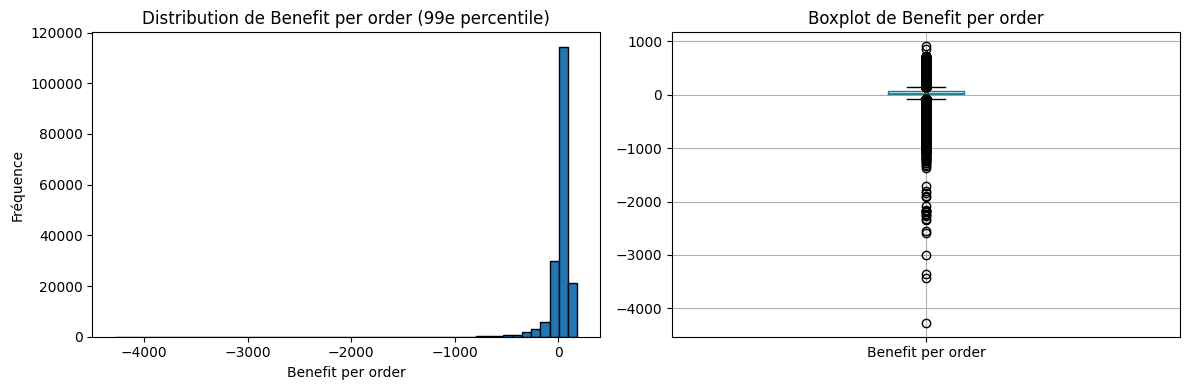

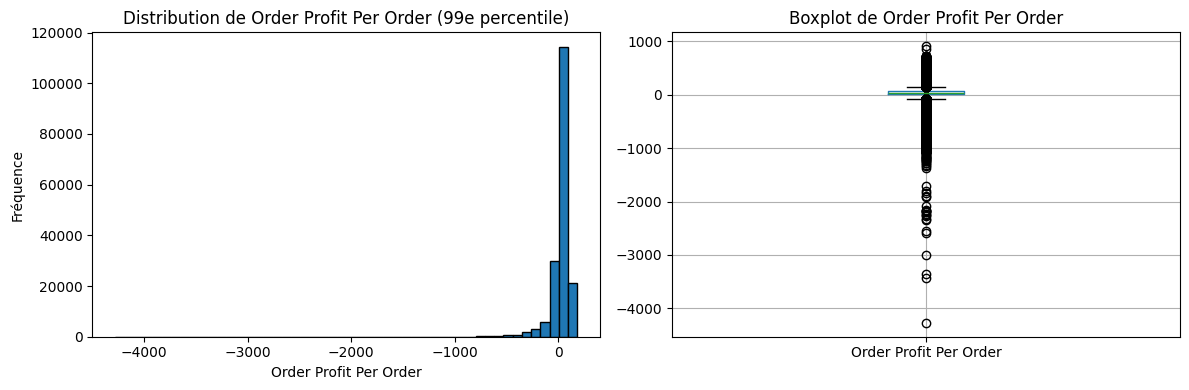

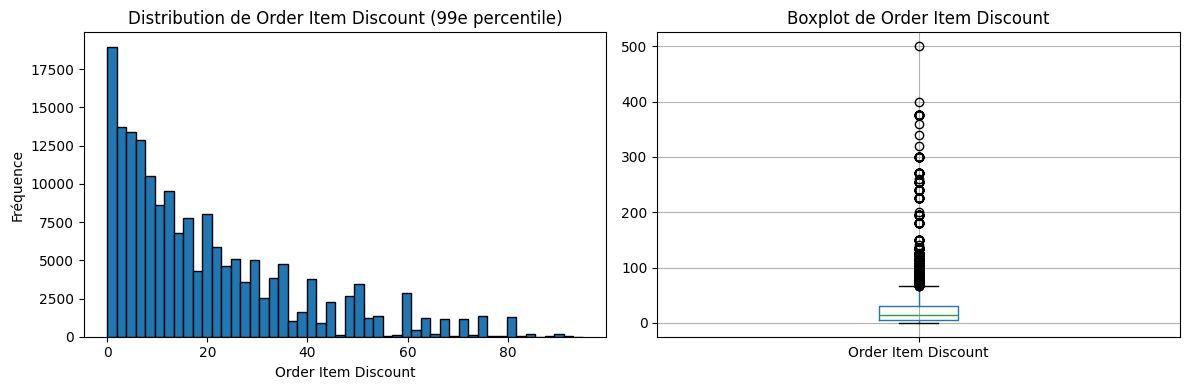

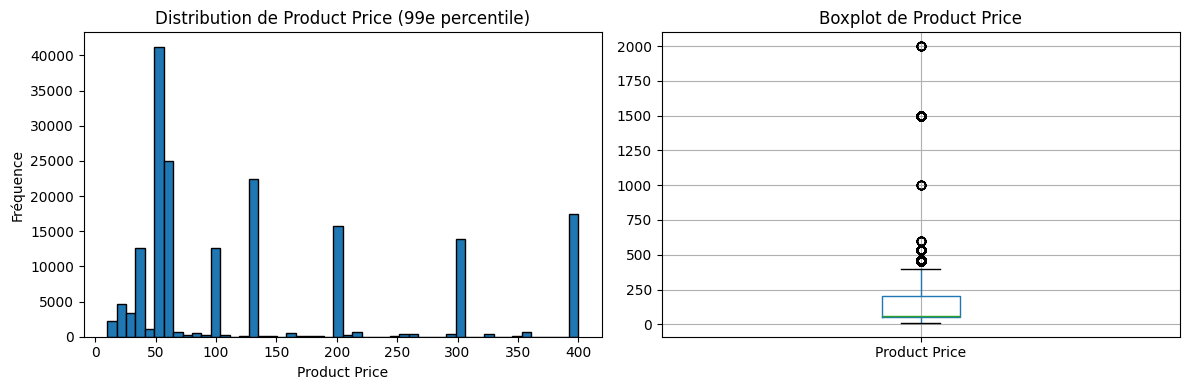

In [25]:
import matplotlib.pyplot as plt

cols_to_plot = ['Benefit per order', 'Order Profit Per Order', 'Order Item Discount', 'Product Price']

for col in cols_to_plot:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogramme (99e percentile)
    filtered = df[col][df[col] < df[col].quantile(0.99)]
    axes[0].hist(filtered, bins=50, edgecolor='black')
    axes[0].set_title(f'Distribution de {col} (99e percentile)')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Fréquence')
    
    # Boxplot
    df.boxplot(column=col, ax=axes[1])
    axes[1].set_title(f'Boxplot de {col}')
    
    plt.tight_layout()
    plt.show()

## 6. Sommaire

### Remarques préliminaires sur des colonnes particulières
- **`Customer Email`** et **`Customer Password`** : toutes les valeurs sont `"XXXXXXXXX"` (données factices). 
- **`Product Status`** : toutes les valeurs sont `0` (colonne constante). 

---

### Colonnes numériques présentant un comportement très aberrant (outliers flagrants)

Seules les colonnes suivantes montrent des extrêmes très marqués (min/max très éloignés des percentiles) :

- **`Benefit per order`** / **`Order Profit Per Order`**  
  - Min = -4274,98 ; Max = 911,80 ; 18,7 % de valeurs négatives.  
  - **Graphiques** :  
    - *Boxplot* : médiane à 0, boîte très étroite (−50 à +50), moustache inférieure jusqu’à −1200, nombreux outliers jusqu’à −4200.  
    - *Histogramme* : pic massif à 0 (fréquence > 110 000), longue traîne vers les négatifs.  
  → La grande majorité des commandes ont un bénéfice nul ou faible, mais une minorité génère des pertes importantes.

- **`Order Item Discount`**  
  - Max = 500 (75e percentile = 29,99).  
  - **Graphiques** :  
    - *Boxplot* : médiane très basse (0–5), boîte étroite (0–35), moustache supérieure vers 60‑70, nombreux outliers jusqu’à 500.  
    - *Histogramme* : décroissant, pic à 0–5 (≈18 000), puis diminution irrégulière.  
  → La plupart des articles sont vendus sans remise ou avec une faible remise ; quelques cas extrêmes (remises énormes) sont rares.

- **`Product Price`**  
  - Max = 1999,99 (75e percentile = 199,99).  
  - Top 5 : 1999,99 (répété 5 fois).  
  - **Graphiques** :  
    - *Boxplot* : médiane ≈ 100‑120, boîte de 40‑50 à 220‑250, moustache supérieure vers 400‑450, outliers élevés jusqu’à 2000.  
    - *Histogramme* : multimodal, pics à 40‑60, 130‑150, 200, 300, 400 ; creux entre ces paliers.  
  → Prix regroupés en gammes distinctes ; quelques produits très chers (jusqu’à 2000) sont rares.



---

### Colonnes catégorielles – nombre de valeurs uniques et détail pour celles ayant ≤ 20 uniques

Liste des colonnes catégorielles analysées (d’après `categorical_for_analysis`) :

| Colonne | Nb valeurs uniques | Détail des fréquences (≤20 uniques) |
|--------|-------------------|--------------------------------------|
| **`Type`** | 4 | DEBIT: 69295, TRANSFER: 49883, PAYMENT: 41725, CASH: 19616 |
| **`Delivery Status`** | 4 | Late delivery: 98977, Advance shipping: 41592, Shipping on time: 32196, Shipping canceled: 7754 |
| **`Customer Country`** | 2 | EE. UU.: 111146, Puerto Rico: 69373 |
| **`Customer Segment`** | 3 | Consumer: 93504, Corporate: 54789, Home Office: 32226 |
| **`Market`** | 5 | LATAM: 51594, Europe: 50252, Pacific Asia: 41260, USCA: 25799, Africa: 11614 |
| **`Order Status`** | 9 | COMPLETE: 59491, PENDING_PAYMENT: 39832, PROCESSING: 21902, PENDING: 20227, CLOSED: 19616, ON_HOLD: 9804, SUSPECTED_FRAUD: 4062, CANCELED: 3692, PAYMENT_REVIEW: 1893 |
| **`Shipping Mode`** | 4 | Standard Class: 107752, Second Class: 35216, First Class: 27814, Same Day: 9737 |
| **`Department Name`** | 11 | Fan Shop: 66861, Apparel: 48998, Golf: 33220, Footwear: 14525, Outdoors: 9686, Fitness: 2479, Discs Shop: 2026, Technology: 1465, Pet Shop: 492, Book Shop: 405, Health and Beauty: 362 |
| `Category Name` | 50 | (trop de valeurs – non détaillé) |
| `Customer City` | 563 | (non détaillé) |
| `Customer Fname` | 782 | (non détaillé) |
| `Customer State` | 46 | (non détaillé) |
| `Customer Street` | 7458 | (non détaillé) |
| `Order City` | 3597 | (non détaillé) |
| `Order Country` | 164 | (non détaillé) |
| `Order Region` | 23 | (non détaillé) |
| `Order State` | 1089 | (non détaillé) |
| `Product Image` | 118 | (non détaillé) |
| `Product Name` | 118 | (non détaillé) |

*(`Customer Lname` a été analysé séparément : 1109 noms uniques, `Smith` très fréquent.)*

---

### Synthèse des outliers

- **`Benefit per order` / `Order Profit Per Order`** : distribution ultra‑concentrée autour de 0, longue traîne négative avec des pertes jusqu’à −4200. Ces pertes sont rares mais réelles (promotions, retours, etc.).  
- **`Order Item Discount`** : remises généralement faibles (<30), mais quelques valeurs extrêmes atteignent 500 (peu fréquentes).  
- **`Product Price`** : prix par paliers ; des produits très chers (jusqu’à 2000) existent mais sont marginaux.


---

### Récapitulatif des décisions de nettoyage pour le Sprint 2

- **Supprimer les colonnes** :  
  - `Order Zipcode` (86% de nulls)  
  - `Product Description` (100% null)  
  - `Customer Email` et `Customer Password` (valeurs constantes factices)  
  - `Product Status` (toujours 0)  
  - `Order Customer Id`, `Order Item Cardprod Id` et `Product Category Id` (redondants)

- **Convertir les types** :  
  - `order date (DateOrders)` et `shipping date (DateOrders)` → `datetime`

- **Gérer les valeurs manquantes** :  
  - `Customer Zipcode` : 3 lignes avec null → supprimer ces lignes (impact négligeable)  
  - `Customer Lname` : 8 lignes avec null → supprimer ces lignes (ou supprimer la colonne)



# Cardinalité & Key Candidates



  
  - `Order Item Id`  → **clé primaire** candidate de la table `Order_Details`.  
  

  
  - `Order Id`  → **clé étrangère** vers `Order`.  
  - `Customer Id`  → **clé étrangère** vers `Customer`.  
  - `Product Card Id`  → **clé étrangère** vers `Product`.  
  

- **Colonnes avec faible cardinalité** :  
  - `Type` (4)  
  - `Delivery Status` (4)  
  - `Customer Country` (2)  
  - `Customer Segment` (3)  
  - `Market` (5)  
  - `Order Status` (9)  
  - `Shipping Mode` (4)  
  - `Department Name` (11)  
  - `Late_delivery_risk` (2)   
  → Ces colonnes serviront de **dimensions** ou **indicateurs binaires** dans le modèle.



**Conclusion pour l’ERD** :  
- Clé primaire de `Order_Details` = `Order Item Id`.  
- Clés étrangères : `Order Id` (vers `Order`), `Customer Id` (vers `Customer`), `Product Card Id` (vers `Product`).  


# Relationships & Cardinalities

In [26]:

from pyspark.sql.functions import countDistinct, col
# 1. Nombre d'items par commande 

items_per_order = df_spark.groupBy("Order Id").agg(
    countDistinct("Order Item Id").alias("items_count")
)
print("=== Statistiques du nombre d'items par commande ===")
items_per_order.describe().show()


# 2. Nombre de commandes par client

orders_per_customer = df_spark.groupBy("Customer Id").agg(
    countDistinct("Order Id").alias("orders_count")
)
print("=== Statistiques du nombre de commandes par client ===")
orders_per_customer.describe().show()


# 3. Nombre de fois qu'un produit a été commandé 

product_orders = df_spark.groupBy("Product Card Id").agg(
    countDistinct("Order Id").alias("times_ordered")
)
print("=== Statistiques du nombre de commandes par produit ===")
product_orders.describe().show()


# 4. Relation Commande -> Livraison : une commande a-t-elle plusieurs livraisons ?
#    En théorie, une commande n'a qu'une seule date de livraison.
#    On compte le nombre de dates de livraison distinctes par commande.

shipments_per_order = df_spark.groupBy("Order Id").agg(
    countDistinct("shipping date (DateOrders)").alias("shipments_count")
)
# Compter les commandes qui auraient plus d'une livraison
multi_ship = shipments_per_order.filter(col("shipments_count") > 1).count()
print(f"=== Nombre de commandes avec plus d'une date de livraison : {multi_ship} ===")
if multi_ship == 0:
    print("Relation 1:1 entre Commande et Livraison.")
else:
    print("Attention : certaines commandes ont plusieurs livraisons.")

# 5. Nombre de villes de livraison différentes par client

cities_per_customer = df_spark.groupBy("Customer Id").agg(
    countDistinct("Order City").alias("nb_cities")
)
print("=== Statistiques du nombre de villes différentes par client ===")
cities_per_customer.describe().show()

=== Statistiques du nombre d'items par commande ===
+-------+-----------------+-----------------+
|summary|         Order Id|      items_count|
+-------+-----------------+-----------------+
|  count|            65752|            65752|
|   mean|39311.90421584134|2.745452609806546|
| stddev|22607.33444487883|1.478363367878195|
|    min|                1|                1|
|    max|            77204|                5|
+-------+-----------------+-----------------+

=== Statistiques du nombre de commandes par client ===
+-------+-----------------+------------------+
|summary|      Customer Id|      orders_count|
+-------+-----------------+------------------+
|  count|            20652|             20652|
|   mean|10400.28592872361|3.1838078636451677|
| stddev|5993.106224684906|2.4306991097824806|
|    min|                1|                 1|
|    max|            20757|                15|
+-------+-----------------+------------------+

=== Statistiques du nombre de commandes par produit ==

## Conclusion

### Résultats des agrégations (PySpark)

- **Items par commande** :  
  - Nombre de commandes distinctes : 65 752  
  - Moyenne d’items par commande : **2,75** (min 1, max 5)  
  → Relation **1:N** entre `Order` (en‑tête) et `Order_Details` (lignes).

- **Commandes par client** :  
  - Nombre de clients distincts : 20 652  
  - Moyenne de commandes par client : **3,18** (min 1, max 15)  
  → Relation **1:N** entre `Customer` et `Order`.

- **Commandes par produit** :  
  - Nombre de produits distincts : **118**  
  - Moyenne d’apparitions d’un produit dans les commandes : **1353,9** (min 8, max 20 359)  
  → Relation **1:N** entre `Product` et `Order_Details` (un produit peut être dans plusieurs commandes).

- **Livraison par commande** :  
  - Aucune commande n’a plus d’une date de livraison (`0` commandes avec >1 livraison).  
  → Relation **1:1** entre `Order` et `Shipment` (une commande est livrée une seule fois).

- **Villes de livraison par client** :  
  - Moyenne de villes différentes par client : **3,17** (min 1, max 15)  
  → Un client peut commander depuis plusieurs villes (relation 1:N entre `Customer` et `Order City`).

### Implications pour l’ERD
- Tables `Order` et `Order_Details` liées par `Order Id` (1:N).  
- Tables `Customer` et `Order` liées par `Customer Id` (1:N).  
- Tables `Product` et `Order_Details` liées par `Product Card Id` (1:N).  
- Tables `Order` et `Shipment` liées par `Order Id` (1:1)  
- La dimension `Order City` peut être rattachée à `Order` ou à `Customer` .


# Entity Discovery

### Entités identifiées et colonnes associées

**Client** (`Customer`)  
- `Customer Id`, `Customer Fname`, `Customer Lname`, `Customer Segment`  
- `Customer City`, `Customer State`, `Customer Country`, `Customer Zipcode`  
- `Customer Street`, `Latitude`, `Longitude` 

**Produit** (`Product`)  
- `Product Card Id`, `Product Name`, `Product Price`  
- `Category Id`, `Category Name`, `Department Id`, `Department Name`  
- `Product Image`, 

**Commande (en‑tête)** (`Order`)  
- `Order Id`, `order date (DateOrders)`  
- `Order Status`, `Market`, `Order Region`, `Order City`, `Order State`, `Order Country`

**Détail de commande** (`Order_Details`)  
- `Order Item Id` (PK), `Order Id` (FK), `Product Card Id` (FK)  
- `Order Item Quantity`, `Sales`, `Order Item Discount`, `Order Item Discount Rate`  
- `Order Item Product Price`, `Order Item Profit Ratio`, `Order Item Total`, `Order Profit Per Order`

**Livraison** (`Shipment`)  
- `Shipping Mode`, `Delivery Status`, `Late_delivery_risk`  
- `Days for shipping (real)`, `Days for shipment (scheduled)`, `shipping date (DateOrders)`


# Data Quality & Cleaning Plan


- Supprimer les colonnes `Product Description` (100% de valeurs manquantes) et `Order Zipcode` (>86% de valeurs manquantes).  
- Supprimer les colonnes factices ou constantes : `Customer Email`, `Customer Password` (toutes les valeurs sont `"XXXXXXXXX"`), `Product Status` (toujours `0`).  
- Supprimer les colonnes redondantes : `Order Customer Id` (identique à `Customer Id`), `Order Item Cardprod Id` (identique à `Product Card Id`), `Product Category Id` (identique à `Category Id`).  
- Convertir les colonnes `order date (DateOrders)` et `shipping date (DateOrders)` du type `string` vers `datetime`.  
- Gérer les très rares valeurs manquantes (moins de 0,005%) : supprimer les 8 lignes où `Customer Lname` est `null`, et les 3 lignes où `Customer Zipcode` est `null`.  
- Conserver les outliers identifiés (profits très négatifs, remises extrêmes, prix très élevés) car ils reflètent des cas métier réels (promotions, retours, produits haut de gamme).  

# Normalization Check 

### Rappel des règles
- **2NF** : Dans une table avec une clé primaire composée (plusieurs colonnes), les autres colonnes doivent dépendre de toute la clé, pas seulement d’une partie.  
  → Ici, toutes nos clés primaires sont simples, donc toutes les tables sont déjà en 2NF.

- **3NF** : Une colonne non‑clé ne doit pas dépendre d’une autre colonne non‑clé (pas de dépendance transitive).

### Vérification de nos tables

| Table | Clé primaire | Problème ? | Correction |
|-------|--------------|------------|-------------|
| `Customer` | `Customer Id` | Aucun | – |
| `Product` | `Product Card Id` | `Category Name` dépend de `Category Id` (non‑clé), `Department Name` dépend de `Department Id` (non‑clé). → **Violation de la 3NF** | Créer les tables `Category` et `Department` |
| `Order` | `Order Id` | Aucun | – |
| `Order_Details` | `Order Item Id` | Aucun | – |
| `Shipment` | `Order Id` | Aucun | – |

### Nouvelles tables à créer pour respecter la 3NF
- **`Category`** : `Category Id` (PK), `Category Name`
- **`Department`** : `Department Id` (PK), `Department Name`

La table `Product` gardera `Category Id` et `Department Id` comme clés étrangères (au lieu des noms).

### Schéma final normalisé (3NF)
- `Customer`
- `Product` (avec `Category Id` FK, `Department Id` FK)
- `Category`
- `Department`
- `Order`
- `Order_Details`
- `Shipment`